### Import Dependencies

In [1]:
from pydantic import BaseModel, Field

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode

from langchain_core.messages import AIMessage, ToolMessage
from langchain_core.messages import convert_to_openai_messages, convert_to_messages
from langgraph.types import Send

from jinja2 import Template
from typing import Literal, Dict, Any, Annotated, List
from IPython.display import Image, display
from operator import add
from openai import OpenAI

import random
import ast
import inspect
import instructor
import json

import openai

from utils.utils import get_tool_descriptions, format_ai_message

from qdrant_client import QdrantClient
from qdrant_client import models
from qdrant_client.models import Filter, FieldCondition, MatchValue, VectorParams, Distance, SparseVectorParams, Modifier, PayloadSchemaType, PointStruct, Document, Prefetch, FusionQuery

from langsmith import traceable

### Query Expansion (Parallel Execution)

In [2]:
class State(BaseModel):
    expanded_query: List[str] = []
    retrieved_context: Annotated[List[str], add] = []
    initial_query: str = ""
    answer: str = ""
    question_relevant: bool = False
    query: str = ""
    k: int = 10

### Query Expansion / Rewriting Node

In [3]:
class QueryExpandResponse(BaseModel):
    statements: List[str]

In [4]:
@traceable(
    name="query_expansion",
    run_type="llm",
    metadata={"ls_provider": "openai", "ls_model_name": "gpt-4.1-mini"}
)
def query_expansion_node(state: State) -> dict:

    prompt_template = """You are a query expansion module in a shopping assistant. Your job is to rewrite a customer's query into distinct statements for semantic product search.

## Instructions

- Expand the question into 1-5 concise statements.
- Each statement should capture a separate product or attribute from the query.
- Use natural product-description language.
- Do not produce multiple statements that express the same intent.

## Examples

Question: "Can I get earphones for me and a waterproof speaker?"
Statements:
- "Personal earphones"
- "Waterproof speaker"

Question: "I need a warm winter jacket for hiking"
Statements:
- "Insulated winter jacket"
- "Hiking outerwear for cold weather"

Question: "Do you have any toys?"
Statements:
- "Toys"

<question>
{{ query }}
</question>
"""

    template = Template(prompt_template)

    prompt = template.render(
        query=state.initial_query
    )

    client = instructor.from_provider(
        "openai/gpt-4.1-mini"
    )

    response, raw_response = client.create_with_completion(
        messages=[
            {"role": "system", "content": prompt}
        ],
        response_model=QueryExpandResponse
    )
 
    return {
        "expanded_query": response.statements
    }

In [5]:
def query_expand_conditional_edges(state: State) -> dict:

    send_messages = []

    for query in state.expanded_query:
        send_messages.append(
            Send(
                "retriever_node",
                {
                    "query": query,
                    "k": 10
                }
            )
        )

    return send_messages

### Retriever Node

In [6]:
@traceable(
    name="embed_query",
    run_type="embedding",
    metadata={"ls_provider": "openai", "ls_model_name": "text-embedding-3-small"}
)
def get_embedding(text, model="text-embedding-3-small"):    
    response = openai.embeddings.create(
        input=text,
        model=model,
    )

    return response.data[0].embedding


@traceable(
    name="retrieve_data",
    run_type="retriever"
)
def retriever_node(state: State) -> dict:

    qdrant_client = QdrantClient(url="http://localhost:6333")

    query_embedding = get_embedding(state["query"])

    results = qdrant_client.query_points(
        collection_name="Amazon-items-collection-01-hybrid-search",
        prefetch=[
            Prefetch(
                query=query_embedding,
                using="text-embedding-3-small",
                limit=20
            ),
            Prefetch(
                query=Document(
                    text=state["query"],
                    model="qdrant/bm25"
                ),
                using="bm25",
                limit=20
            )
        ],
        query=models.RrfQuery(rrf=models.Rrf(weights=[1,1])),
        limit=state["k"]
    )

    retrieved_context_ids = []
    retieved_context = []
    similarity_scores = []
    retrieved_context_ratings = []

    for result in results.points:
        retrieved_context_ids.append(result.payload["parent_asin"])
        retieved_context.append(result.payload["description"])
        similarity_scores.append(result.score)
        retrieved_context_ratings.append(result.payload["average_rating"])

    formatted_context = ""

    for id, chunk, rating in zip(retrieved_context_ids, retieved_context, retrieved_context_ratings):
        formatted_context += f"- ID: {id}, rating: {rating}, description: {chunk}\n"

    return {
        "retrieved_context": [formatted_context]
    }

### Aggregator Node

In [7]:
class AggregatorResponse(BaseModel):
    answer: str

In [8]:
@traceable(
    name="generate_answer",
    run_type="llm",
    metadata={"ls_provider": "openai", "ls_model_name": "gpt-4.1-mini"}
)
def aggregator_node(state: State) -> dict:

    preprocessed_context = "\n".join(state.retrieved_context)

    prompt_template = """You are a shopping assistant that can answer questions about the products in stock.

You will be given a question and a list of context.

### Instructions

- You need to answer the question based on the provided context only.
- Never use word context and refer to it as the available products.
- The answer to the question should contain detailed information about the product and returned with detailed specification in bullet points.

### Context

{{ preprocessed_context }}

### Question

{{ question }}
"""

    template = Template(prompt_template)

    prompt = template.render(
        preprocessed_context=preprocessed_context,
        question=state.initial_query
    )

    client = instructor.from_provider(
        "openai/gpt-4.1-mini"
    )

    response, raw_response = client.create_with_completion(
        messages=[
            {"role": "system", "content": prompt}
        ],
        response_model=AggregatorResponse
    )
 
    return {
        "answer": response.answer
    }

### User Intent Router Node

In [9]:
class IntentRouterResponse(BaseModel):
    question_relevant: bool
    answer: str

In [10]:
@traceable(
    name="route_intent",
    run_type="llm",
    metadata={"ls_provider": "openai", "ls_model_name": "gpt-4.1-mini"}
)
def intent_router_node(state: State) -> dict:

    prompt_template = """You are a relevance router for a shopping assistant that answers questions about products in stock.

## Instructions

- Determine whether the question is about products, inventory, or purchasing.
- Questions about product features, availability, pricing, comparisons, and recommendations are relevant.
- Questions about store policies, personal advice, or unrelated topics are not relevant.

## Examples

Question: "Do you have running shoes under $100?"
Relevant: yes

Question: "What's the weather like today?"
Relevant: no - not related to products

Question: "Can you help me write an essay?"
Relevant: no - not related to products

Question: "Which laptop has the best battery life?"
Relevant: yes

Question: "What's your return policy?"
Relevant: no - about store policy, not product information

<question>
{{ query }}
</question>
"""

    template = Template(prompt_template)

    prompt = template.render(
        query=state.initial_query
    )

    client = instructor.from_provider(
        "openai/gpt-4.1-mini"
    )

    response, raw_response = client.create_with_completion(
        messages=[
            {"role": "system", "content": prompt}
        ],
        response_model=IntentRouterResponse
    )
 
    return {
        "question_relevant": response.question_relevant,
        "answer": response.answer
    }

In [11]:
def intent_router_conditional_edges(state: State) -> str:

    if state.question_relevant:
        return "query_expansion_node"
    else:
        return "end"

### Graph

In [12]:
workflow = StateGraph(State)
workflow.add_node("query_expansion_node", query_expansion_node)
workflow.add_node("retriever_node", retriever_node)
workflow.add_node("aggregator_node", aggregator_node)
workflow.add_node("intent_router_node", intent_router_node)

workflow.add_edge(START, "intent_router_node")

workflow.add_conditional_edges(
    "intent_router_node", 
    intent_router_conditional_edges,
    {
        "query_expansion_node": "query_expansion_node",
        "end": END
    }
)

workflow.add_conditional_edges("query_expansion_node", query_expand_conditional_edges)

workflow.add_edge("retriever_node", "aggregator_node")
workflow.add_edge("aggregator_node", END)

graph = workflow.compile()

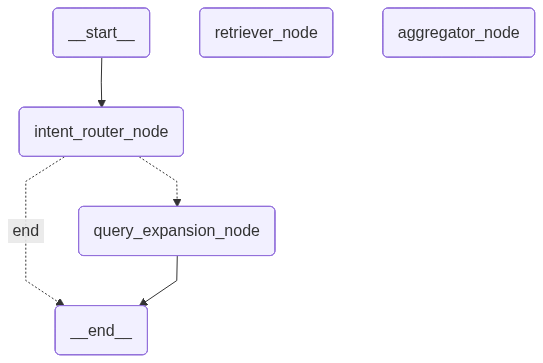

In [13]:
display(Image(graph.get_graph().draw_mermaid_png()))

### Invoke

In [14]:
initial_state = {
    "initial_query": "Can I get a tablet for my kid, a watch for me a laptop for my wife and a waterproof speaker for our party next week?"
}
result = graph.invoke(initial_state)

In [15]:
result

{'expanded_query': ['Tablet for kids',
  'Watch for adults',
  'Laptop for home use',
  'Waterproof speaker for parties'],
 'retrieved_context': ['- ID: B0C3XYD574, rating: 4.4, description: ROWT Tablet for Kids 10 inch Kids Tablet 2GB RAM 32GB ROM Android 11 6000mAh Wi-Fi, Bluetooth, Kid-Proof Case(Blue) 【Kids\' Safety & Parental Controls】Looking for a safe tablet that\'s easy for your kids to use? This 10-inch tablet for kids is GMS-certified, has password protection, a content filter, and a one-button lock screen, making it easier for parents to keep an eye on their kids activities and learning. 【Creative Educational Content】Our kids tablet provides access to a range of age-appropriate creative kids content such as drawing, educational games, eBooks, learning videos, math tools, and much more! Learning through play is best for kids to understand the world. 【Powerful Configuration & Full Access to Google】This Android 11 kids tablet has an HD 1280x800 IPS touchscreen, 1.6 GHz Quad-Cor

In [16]:
print(result["answer"])

Yes, you can get all of these items from the available products:

1. Tablet for your kid:
- ROWT Tablet for Kids 10 inch Kids Tablet
  - 10.1-inch HD 1280x800 IPS touchscreen
  - Android 11 OS
  - 2GB RAM, 32GB ROM storage
  - 6000mAh battery
  - Kid-proof case included
  - Parental controls and kids safety features
  - Access to Google Play for apps like Gmail, Disney+, YouTube

2. Watch for you:
- JrTrack Cosmo 2 Kid’s Smartwatch (also suitable as a kids watch)
  - 4G phone calling & text messaging
  - GPS tracker watch
  - Pre-installed SIM card (requires activation with Cosmo data plan)
  - Safe and secure with GPS tracking, safe zones, approved contacts
  - 2-way communication, touch screen, texting keyboard
  - Front facing camera

3. Laptop for your wife:
- jumper Laptop, 16 Inch FHD IPS Display
  - Intel Celeron Quad Core CPU
  - 4GB DDR4 RAM, 128GB storage
  - Windows 11 with 1-year Office 365 subscription
  - 4 stereo speakers
  - Large battery capacity and good connectivity 

In [17]:
initial_state = {
    "initial_query": "What is the weather today?"
}
result = graph.invoke(initial_state)

In [18]:
result

{'retrieved_context': [],
 'initial_query': 'What is the weather today?',
 'answer': 'The question about the weather today is not relevant because it is not related to products, inventory, or purchasing.',
 'question_relevant': False}

In [19]:
print(result["answer"])

The question about the weather today is not relevant because it is not related to products, inventory, or purchasing.
